# Operator Breakdown Analysis: Hymba vs. Zamba2

This notebook profiles and visualizes the **GPU kernel time breakdown** of two SSM-hybrid LLM architectures across increasing sequence lengths during the **prefill phase**:

| Model | Architecture | Hybrid design |
|-------|-------------|---------------|
| Hymba | SSM + Attention hybrid | Interleaved Mamba-2 SSM and multi-head attention heads per layer |
| Zamba2 | SSM + Attention hybrid | Shared transformer layers interleaved with Mamba-2 blocks |

Both models blend **SSM recurrence** with **attention**, making their kernel-level compute profiles richer than pure-SSM models. Execution time is decomposed into:

| Category | Description |
|----------|-------------|
| **GEMM** | General Matrix Multiplications (linear projections, convolutions) |
| **SSM_Scan** | State space model recurrence scan (selective scan kernel) |
| **activation** | Activation functions (SiLU, GeLU, etc.) |
| **arithmetic** | Element-wise and reduction ops (add, mul, exp, sum, …) |
| **memory** | Data movement ops (reshape, permute, cat, copy, …) |
| **nomralization** | Layer norm and RMS norm |
| **embedding** | Token embedding lookup |
| **logit_computation** | Softmax for output logits |
| **pooling / interpolation / roi / other** | Miscellaneous ops |

Profiling data is read from `../../profile_data/`.  Only directories matching `hymba_*` and `zamba2_*` are processed.
Figures are saved as both annotated (with labels) and paper-ready (clean) versions.

## 1. Imports and Configuration

`MODELS` maps each model name to the sequence lengths available in `profile_data/`.

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Directory where the profiling data is stored (relative to this notebook)
prof_dir = '../../profile_data'

# Models and their available sequence lengths
MODELS = {
    'hymba':  [256, 512, 1024, 2048, 4096, 8192, 16384],
    'zamba2': [256, 512, 1024, 2048, 4096, 8192, 16384, 32768],
}

# Convenience aliases
hymba_seq_lengths  = MODELS['hymba']
zamba2_seq_lengths = MODELS['zamba2']

print("Profile data directory:", os.path.abspath(prof_dir))
print("Models to analyse:", list(MODELS.keys()))

Profile data directory: /home/sap/prj/SSM-characterization/profile_data
Models to analyse: ['hymba', 'zamba2']


## 2. Operator Category Definitions and Color Schemes

Operator lists enumerate the PyTorch and Triton kernel names that belong to each category.  
The dicts `non_gemm_ops_dict`, `gemm_ops_dict`, and `ops_dict` are used downstream by the aggregation functions.

In [18]:
gemm_file     = "gemm.csv"
non_gemm_file = "non_gemm.csv"
ssm_scan_file = "ssm_scan.csv"

# Primary color palette (used for paper figures)
color_scheme = {
    "GEMM":             '#4C443C',
    "NonGEMM":          '#DEB841',
    "SSM_Scan":         '#E48D9C',
    "nomralization":    '#DEB841',
    "activation":       '#769FB6',
    "arithmetic":       '#D16666',
    "interpolation":    '#999AC6',
    "memory":           '#55917F',
    "other":            '#32373B',
    "pooling":          '#BDBBB6',
    "embedding":        '#83D628',
    "logit_computation":'#254E70',
    "roi":              '#FAE8EB',
}

# ── Operator lists ──────────────────────────────────────────────────────────
gemm_ops = [
    "aten::mm", "aten::matmul", "aten::bmm", "aten::linear", "aten::addmm",
    "aten::addbmm", "aten::baddbmm", "aten::mv", "aten::dot", "aten::ger",
    "aten::matmul.out", "aten::scaled_dot_product_attention",
    "aten::conv1d", "aten::conv2d", "aten::conv3d", "aten::conv_tbc",
    "aten::conv_transpose1d", "aten::conv_transpose2d", "aten::conv_transpose3d",
    "aten::slow_conv3d", "aten::slow_conv_dilated2d", "aten::slow_conv_dilated3d",
    "aten::slow_conv_transpose2d", "aten::slow_conv_transpose3d",
    "aten::thnn_conv2d", "aten::thnn_conv_depthwise2d",
    "aten::scaled_dot_product_attention", "aten::linear",
    'wqlinearmmfunction', "conv1d", "aten::einsum",
]

attention_ops    = [op for op in gemm_ops if "attention" in op]
gemm_ops_no_attn = [op for op in gemm_ops if op not in attention_ops]

act               = ['aten::silu', 'aten::gelu', 'aten::sigmoid', 'aten::relu', 'aten::relu_',
                     'newgeluactivation_prof', 'triton_poi_fused_mul_silu_8', 'aten::softplus']
logit_computation = ['aten::softmax']
norm              = ['aten::layer_norm', 'layernormfn', 'aten::group_norm', 'aten::batch_norm',
                     'llamarmsnorm_prof', "detrfrozenbatchnorm2d_prof", "mixtralrmsnorm_prof",
                     "triton_red_fused__to_copy_add_embedding_mean_mul_pow_rsqrt_0",
                     'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_7',
                     'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_9',
                     'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_10',
                     'zamba2rmsnorm_prof', 'zamba2rmsnormgated_prof', 'qwen2rmsnorm_prof',
                     'mambarmsnorm_prof', 'hymbarmsnorm_prof']
roi               = ['torchvision::roi_align', 'torchvision::nms']
arith             = ['aten::rsub', 'aten::add', 'aten::add_', 'aten::div', 'aten::mul', 'aten::floor',
                     'aten::neg', 'aten::mul_', 'aten::gt', 'aten::sub', 'aten::ge', 'aten::lt',
                     'aten::le', 'aten::eq', 'aten::ne', 'aten::bitwise_not', 'aten::__and__',
                     'aten::is_nonzero', 'aten::any', 'aten::clamp', 'aten::all', 'aten::pow',
                     'aten::sin', 'aten::cos', 'aten::rsqrt', 'aten::sqrt', 'aten::log2', 'aten::exp',
                     'aten::max', 'aten::min', 'aten::cumsum', "aten::mean", "aten::div_",
                     "aten::index_add_", 'aten::__or__', "aten::argmax", 'aten::exponential_',
                     'aten::sum', 'aten::bitwise_and',
                     'triton_red_fused_add_all_eq_masked_fill_1',
                     'triton_poi_fused_add_cat_clone_mul_4',
                     'triton_poi_fused_add_all_bitwise_not_constant_pad_nd_eq_masked_fill_mul_6']
pooling           = ['aten::adaptive_avg_pool1d', 'aten::max_pool2d', 'aten::adaptive_avg_pool2d']
interpolation     = ['aten::upsample_nearest2d', 'aten::upsample_bilinear2d']
embedding         = ['aten::embedding']
mem               = ['aten::slice', 'aten::chunk', 'aten::view', 'aten::permute', 'aten::transpose',
                     'aten::t', 'aten::reshape', 'aten::flatten', 'aten::pad', 'aten::contiguous',
                     'aten::index', 'aten::unsqueeze', 'aten::to', 'aten::cat', 'aten::copy_',
                     'aten::empty', 'aten::expand', 'aten::new_empty', 'aten::new_zeros', 'aten::where',
                     'aten::unbind', 'aten::select', 'aten::new_full', 'aten::masked_fill', 'aten::ones',
                     'aten::fill_', 'aten::full', 'aten::repeat', 'aten::stack', 'aten::arange',
                     'aten::type_as', 'aten::_unique2', 'aten::index_put_', 'aten::zeros', 'aten::zero_',
                     'aten::zeros_like', 'aten::expand_as', 'aten::full_like', 'aten::detach',
                     'aten::detach_', 'aten::split_with_sizes', 'aten::split', 'aten::tensor_split',
                     "aten::one_hot", "aten::scatter", "aten::new_ones", 'aten::squeeze', 'aten::clone',
                     'aten::masked_fill_', 'aten::ones_like', 'aten::empty_like', 'aten::resize_',
                     'triton_poi_fused__to_copy_2', 'triton_poi_fused__to_copy_3',
                     'triton_poi_fused_clone_5', 'triton_poi_fused__to_copy_11',
                     'aten::_unsafe_view', 'aten::item', 'aten::alias', 'aten::concatenate']
other             = ['aten::dropout', 'aten::lift_fresh', 'aten::meshgrid', 'aten::topk', 'aten::sort',
                     'aten::argsort', 'torchdynamo cache lookup', 'torch-compiled region',
                     'aten::_assert_async', 'aten::triu']

non_gemm_ops = act + logit_computation + norm + roi + arith + pooling + interpolation + embedding + mem + other

non_gemm_ops_dict = {
    'activation':       act,
    'logit_computation': logit_computation,
    'nomralization':    norm,
    'arithmetic':       arith,
    'pooling':          pooling,
    'interpolation':    interpolation,
    'embedding':        embedding,
    'memory':           mem,
    'roi':              roi,
    'other':            other,
}

gemm_ops_dict = {"gemm": gemm_ops_no_attn, "attention": attention_ops}

ops_dict = {
    "gemm":             gemm_ops_no_attn,
    "attention":        attention_ops,
    'activation':       act,
    'logit_computation': logit_computation,
    'nomralization':    norm,
    'arithmetic':       arith,
    'pooling':          pooling,
    'interpolation':    interpolation,
    'embedding':        embedding,
    'memory':           mem,
    'roi':              roi,
    'other':            other,
}

print("Operator categories defined:", list(non_gemm_ops_dict.keys()))

Operator categories defined: ['activation', 'logit_computation', 'nomralization', 'arithmetic', 'pooling', 'interpolation', 'embedding', 'memory', 'roi', 'other']


## 3. Utility Functions

- **`filter_dataframes`** — keeps only rows whose `name` is in the given list.
- **`sum_df_append`** — aggregates numeric columns and appends a summary row with a custom name.
- **`check_new_non_gemm`** — prints any kernel names not yet classified in `non_gemm_ops` (useful during profiling exploration).
- **`get_directories`** — lists sub-directories under a path.

In [19]:
def filter_dataframes(df, lst):
    """Keep only rows whose 'name' column is in `lst`."""
    return df[df['name'].isin(lst)]


def sum_df_append(filtered_df, name):
    """Sum all numeric columns, label the row with `name`, and append it to the DataFrame."""
    summed_row = filtered_df.drop(columns=["name"]).sum()
    summed_row["name"] = name
    df = pd.concat([filtered_df, pd.DataFrame([summed_row])], ignore_index=True)
    return df, summed_row.to_frame().T


def check_new_non_gemm(unique_non_gemm):
    """Print any kernel names not yet mapped to a non-GEMM category."""
    new_ops = [op for op in unique_non_gemm if op not in non_gemm_ops]
    print("New Non-GEMM Operators:")
    print(new_ops)


def get_directories(path):
    """Return names of all immediate sub-directories under `path`."""
    return [e for e in os.listdir(path) if os.path.isdir(os.path.join(path, e))]

## 4. Summarize Non-GEMM Operations

`summarize_non_gemm` scans `profile_data/` and processes **only** directories whose prefix matches one of the target models (`hymba`, `zamba2`). For each directory it:

1. Reads `non_gemm.csv` and maps kernels to categories.
2. Aggregates per-category kernel times and appends them to the GEMM/SSM_Scan totals.
3. Writes back:  
   - `summary_<dir>.csv` — full breakdown  
   - `gng_<dir>.csv` — GEMM vs. NonGEMM  
   - `gng_ssm_<dir>.csv` — GEMM vs. NonGEMM vs. SSM_Scan  
   - `pct_<dir>.csv` — percentage breakdown (used for plotting)

In [20]:
def summarize_non_gemm(prof_dir, target_models=None):
    """
    Aggregate non-GEMM kernel times into named categories for every profile
    directory that matches one of the `target_models` prefixes.

    Parameters
    ----------
    prof_dir : str
        Path to the root profile data directory.
    target_models : list of str, optional
        Only process directories whose name starts with one of these prefixes.
        Defaults to all models defined in MODELS.
    """
    if target_models is None:
        target_models = list(MODELS.keys())

    for dir_name in sorted(get_directories(prof_dir)):
        # Filter: only process directories belonging to our target models
        if not any(dir_name.startswith(m) for m in target_models):
            continue

        data_file = f"{prof_dir}/{dir_name}/{non_gemm_file}"
        if not os.path.exists(data_file):
            continue

        df_nongemm    = pd.read_csv(data_file)
        unique_nongemm = df_nongemm['name'].unique().tolist()
        check_new_non_gemm(unique_nongemm)

        df_summary  = pd.read_csv(f"{prof_dir}/{dir_name}/{dir_name}.csv")
        df_gng      = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM'])]
        df_gng_ssm  = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM', 'SSM_Scan'])]
        df_summary  = df_summary[df_summary['name'].isin(['GEMM', 'SSM_Scan'])]

        for group, lst in non_gemm_ops_dict.items():
            df_      = filter_dataframes(df_nongemm, lst)
            df_, summary_row = sum_df_append(df_, group)
            df_summary = pd.concat([df_summary, summary_row], ignore_index=True).drop(
                columns=['Unnamed: 0'], errors='ignore')
            df_.to_csv(f"{prof_dir}/{dir_name}/{group}.csv")

        df_summary.to_csv(f"{prof_dir}/{dir_name}/summary_{dir_name}.csv")
        df_gng.to_csv(f"{prof_dir}/{dir_name}/gng_{dir_name}.csv")
        df_gng_ssm.to_csv(f"{prof_dir}/{dir_name}/gng_ssm_{dir_name}.csv")

        # Compute and write percentage breakdowns
        for df_, out_prefix in [
            (df_summary[["name", "total_time (us)"]],  f"pct_{dir_name}"),
            (df_gng[["name", "total_time (us)"]],       f"gng_pct_{dir_name}"),
            (df_gng_ssm[["name", "total_time (us)"]],  f"gng_ssm_pct_{dir_name}"),
        ]:
            total = df_['total_time (us)'].sum()
            df_   = df_.copy()
            df_['pct'] = (df_['total_time (us)'] / total) * 100
            df_.to_csv(f"{prof_dir}/{dir_name}/{out_prefix}.csv")


# Run summarization for hymba and zamba2 only
summarize_non_gemm(prof_dir, target_models=['hymba', 'zamba2'])

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['buffer flush', 'NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


## 5. Data Loading Helper

`collect_model_data` reads the pre-computed `pct_<model>_<device>_<bs>_<seqlen>.csv` file for each sequence length and returns a `{seq_len: DataFrame}` dict.  
Missing files are skipped reported.

In [21]:
def collect_model_data(model_name, seq_lengths, batch_size=1, device='cuda'):
    """
    Load percentage-breakdown CSVs for a given model across sequence lengths.

    Returns
    -------
    dict : {seq_len (int): pd.DataFrame}
    """
    data = {}
    for seq_len in seq_lengths:
        fp = (f"{prof_dir}/{model_name}_{device}_{batch_size}_{seq_len}"
              f"/pct_{model_name}_{device}_{batch_size}_{seq_len}.csv")
        if not os.path.exists(fp):
            print(f"  [skip] Not found: {fp}")
            continue
        data[seq_len] = pd.read_csv(fp)
    return data

## 6. Load Hymba Profiling Data

Read per-sequence-length breakdown data for **Hymba** (sequence lengths: 256 → 16 384 tokens).

In [22]:
hymba_data = collect_model_data('hymba', hymba_seq_lengths)
print(f"Hymba — found data for sequence lengths: {list(hymba_data.keys())}")

Hymba — found data for sequence lengths: [256, 512, 1024, 2048, 4096, 8192, 16384]


## 7. Build Hymba Operator Breakdown DataFrame

`create_op_breakdown_df` pivots the per-sequence-length DataFrames into a single table where:
- **rows** = operator categories  
- **columns** = sequence lengths

The result is displayed and saved to `hymba_operator_breakdown.csv` for reproducibility.

In [23]:
def create_op_breakdown_df(model_data):
    """
    Pivot per-sequence-length DataFrames into a single breakdown table.

    Returns
    -------
    pd.DataFrame : rows = operator categories, columns = sequence lengths (sorted)
    """
    all_ops = set()
    for df in model_data.values():
        all_ops.update(df['name'].tolist())

    breakdown_df = pd.DataFrame(index=sorted(all_ops), columns=sorted(model_data.keys()))

    for seq_len, df in model_data.items():
        for _, row in df.iterrows():
            breakdown_df.loc[row['name'], seq_len] = row['pct']

    return breakdown_df.fillna(0)


# Build and save Hymba breakdown
hymba_breakdown = create_op_breakdown_df(hymba_data)
print("Hymba Operator Breakdown by Sequence Length:")
print(hymba_breakdown)
hymba_breakdown.to_csv(f"{prof_dir}/hymba_operator_breakdown.csv")

Hymba Operator Breakdown by Sequence Length:
                       256        512        1024       2048       4096   \
GEMM               16.428063  19.321158  23.285011  23.499846  19.569042   
SSM_Scan            7.550037   9.002175  11.188943  11.557621   8.818286   
activation          0.321569   0.347542   0.348959   0.601946   0.655388   
arithmetic         15.770300  14.735276  13.811708  11.244466  13.115087   
embedding           0.024507   0.025558   0.026735   0.017925   0.011705   
interpolation       0.000000   0.000000   0.000000   0.000000   0.000000   
logit_computation   0.000000   0.000000   0.000000   0.000000   0.000000   
memory             28.482787  25.243355  21.972570  29.923775  40.431184   
nomralization      21.298576  19.510169  17.869255  13.122150  10.473474   
other              10.124160  11.814767  11.496819  10.032273   6.925833   
pooling             0.000000   0.000000   0.000000   0.000000   0.000000   
roi                 0.000000   0.000000   0

/tmp/ipykernel_825061/3026716471.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return breakdown_df.fillna(0)


## 8. Plot Hymba Operator Breakdown (Annotated)

Stacked bar chart with full axis labels, title, and legend.  
**Stacking order:** SSM_Scan (bottom) → GEMM → remaining categories sorted by mean percentage descending.

This version is useful for inspection and slide presentations.

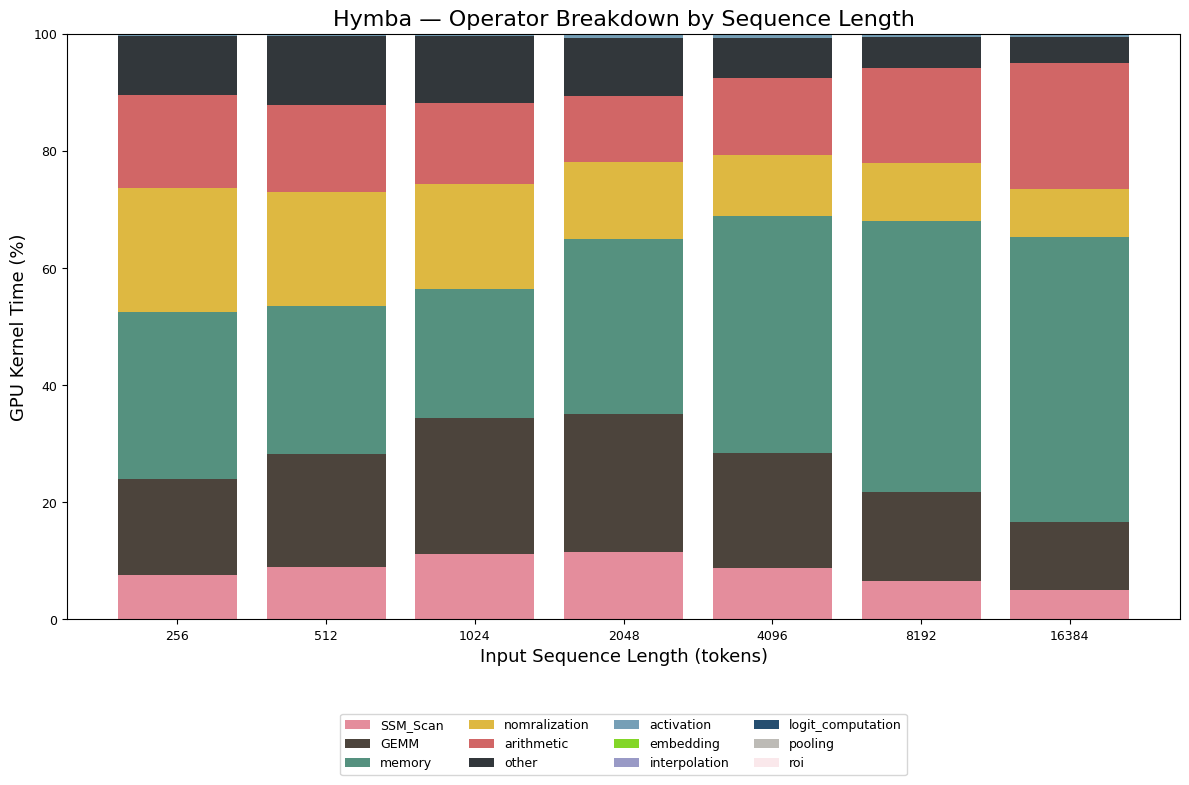

In [32]:
def plot_op_breakdown(breakdown_df, model_name, color_scheme,
                      annotated=True, figsize=(12, 8)):
    """
    Stacked bar chart of GPU kernel-time percentage by sequence length.

    Parameters
    ----------
    breakdown_df : pd.DataFrame
        Rows = operator categories, columns = sequence lengths.
    model_name : str
        Used in the figure title (annotated mode only).
    color_scheme : dict
        Maps operator category name to a hex color string.
    annotated : bool
        If True, show title, axis labels, tick labels, and legend.
        If False, produce a clean paper-ready figure with no annotations.
    figsize : tuple
        Matplotlib figure size.
    """
    fig, ax = plt.subplots(figsize=figsize)
    seq_lengths = [str(x) for x in breakdown_df.columns]

    # Sort: SSM_Scan and GEMM anchored at bottom; rest ordered by mean % descending
    other_ops        = [op for op in breakdown_df.index if op not in ('SSM_Scan', 'GEMM')]
    other_ops_sorted = sorted(other_ops,
                              key=lambda x: breakdown_df.loc[x].astype(float).iloc[0],
                              reverse=True)
    op_order = ['SSM_Scan', 'GEMM'] + other_ops_sorted

    bottom = np.zeros(len(seq_lengths))
    for op in op_order:
        if op in breakdown_df.index:
            values = breakdown_df.loc[op].values.astype(float)
            color  = color_scheme.get(op, color_scheme.get('other', '#32373B'))
            ax.bar(seq_lengths, values, bottom=bottom, label=op, color=color)
            bottom += values

    if annotated:
        ax.set_title(f'{model_name} — Operator Breakdown by Sequence Length', fontsize=16)
        ax.set_xlabel('Input Sequence Length (tokens)', fontsize=13)
        ax.set_ylabel('GPU Kernel Time (%)', fontsize=13)
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=9)
    else:
        ax.tick_params(axis='both', which='major',
                       labelsize=9, labelbottom=False, labelleft=False)

    plt.tight_layout()
    return fig, ax


# Annotated plot — Hymba
fig_hymba_ann, _ = plot_op_breakdown(hymba_breakdown, 'Hymba', color_scheme, annotated=True)
plt.savefig(f"hymba_op_breakdown_annotated.png", bbox_inches='tight', dpi=300)
plt.show()

## 9. Plot Hymba Operator Breakdown (Paper-Ready)

Clean version with all annotations removed — intended for direct embedding into paper figures where captions supply the context.  
Saved to `profile_data/hymba_op_breakdown.png`.

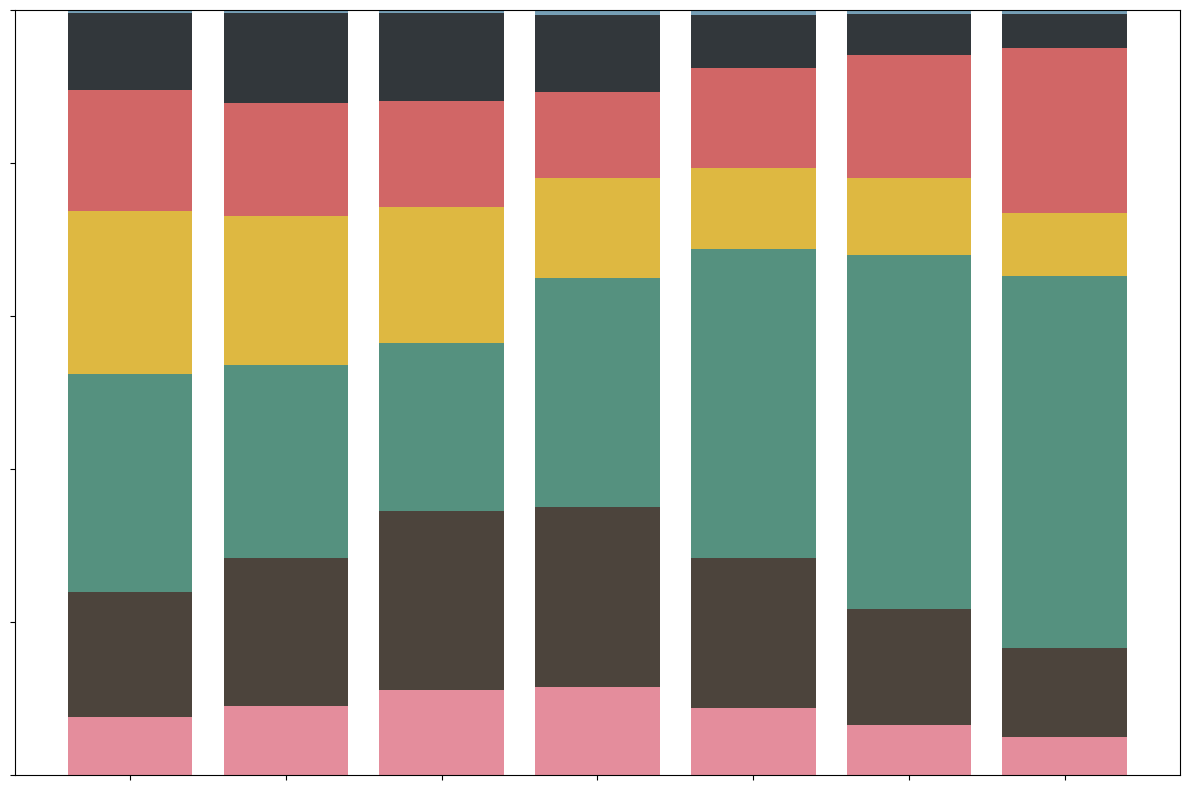

In [33]:
# Paper-ready plot — Hymba (no labels, no legend)
fig_hymba, _ = plot_op_breakdown(hymba_breakdown, 'Hymba', color_scheme, annotated=False)
# plt.savefig(f"{prof_dir}/hymba_op_breakdown.png", bbox_inches='tight', dpi=300)
plt.show()

## 10. Load Zamba2 Profiling Data

Read per-sequence-length breakdown data for **Zamba2** (sequence lengths: 256 → 32 768 tokens).  
Zamba2 covers a wider context range than Hymba due to its efficient hybrid design.

In [27]:
zamba2_data = collect_model_data('zamba2', zamba2_seq_lengths)
print(f"Zamba2 — found data for sequence lengths: {list(zamba2_data.keys())}")

Zamba2 — found data for sequence lengths: [256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


## 11. Build Zamba2 Operator Breakdown DataFrame

Apply `create_op_breakdown_df` to the Zamba2 data and save to `zamba2_operator_breakdown.csv`.

In [34]:
zamba2_breakdown = create_op_breakdown_df(zamba2_data)
print("Zamba2 Operator Breakdown by Sequence Length:")
print(zamba2_breakdown)
zamba2_breakdown.to_csv(f"{prof_dir}/zamba2_operator_breakdown.csv")

Zamba2 Operator Breakdown by Sequence Length:
                       256        512        1024       2048       4096   \
GEMM               27.184745  30.191492  33.519389  33.134257  30.387369   
SSM_Scan           32.643570  28.996154  20.642727  12.371796   7.662052   
activation          0.155369   0.177662   0.186070   0.299395   0.268045   
arithmetic         10.570730  14.706420  25.502606  38.166351  45.345689   
embedding           0.058072   0.050996   0.053675   0.026778   0.016550   
interpolation       0.000000   0.000000   0.000000   0.000000   0.000000   
logit_computation   0.000000   0.000000   0.000000   0.000000   0.000000   
memory              7.259925   5.881775   4.174712   2.631710   1.704881   
nomralization      22.106304  19.975131  15.903110  13.352415  14.592618   
other               0.021285   0.020369   0.017710   0.017299   0.022796   
pooling             0.000000   0.000000   0.000000   0.000000   0.000000   
roi                 0.000000   0.000000   

/tmp/ipykernel_825061/3026716471.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return breakdown_df.fillna(0)


## 12. Plot Zamba2 Operator Breakdown (Annotated)

Annotated stacked bar chart for Zamba2.  
Saved to `profile_data/zamba2_op_breakdown_annotated.png`.

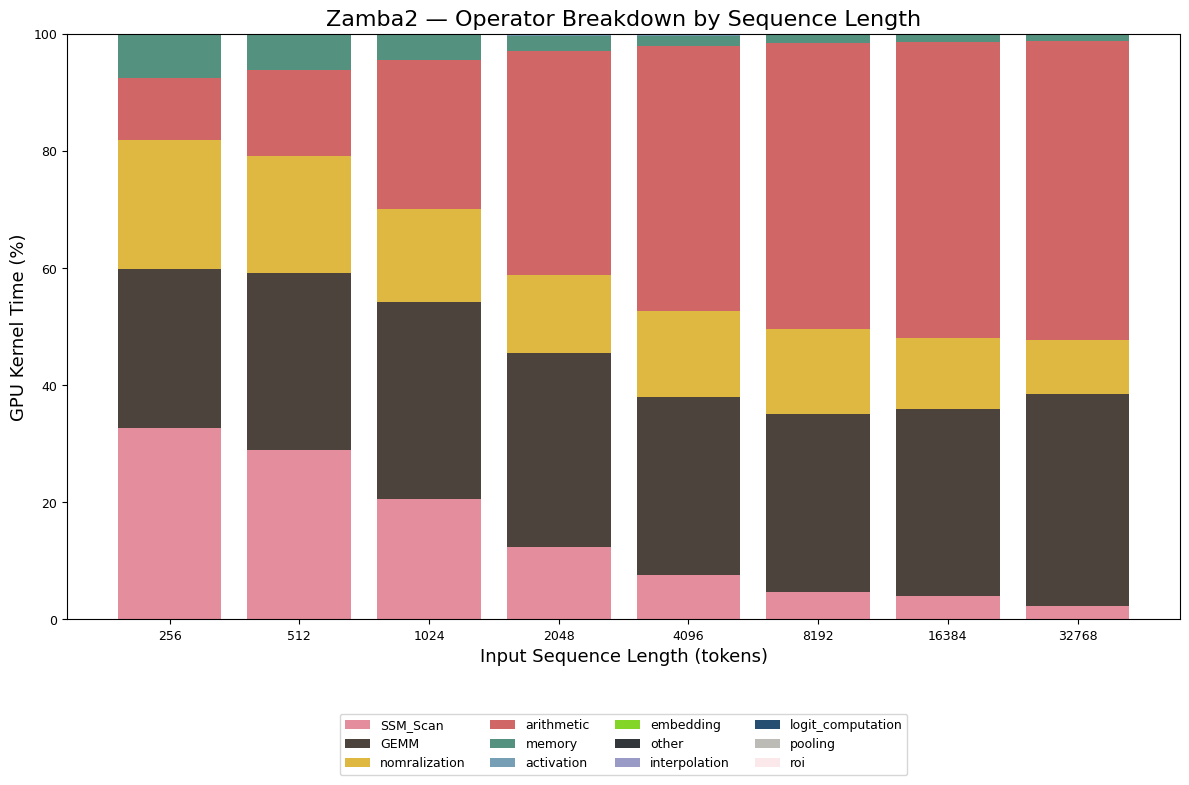

In [35]:
# Annotated plot — Zamba2
fig_zamba2_ann, _ = plot_op_breakdown(zamba2_breakdown, 'Zamba2', color_scheme, annotated=True)
plt.savefig(f"zamba2_op_breakdown_annotated.png", bbox_inches='tight', dpi=300)
plt.show()

## 13. Plot Zamba2 Operator Breakdown (Paper-Ready)

Clean version without annotations.  
Saved to `profile_data/zamba2_op_breakdown.png`.

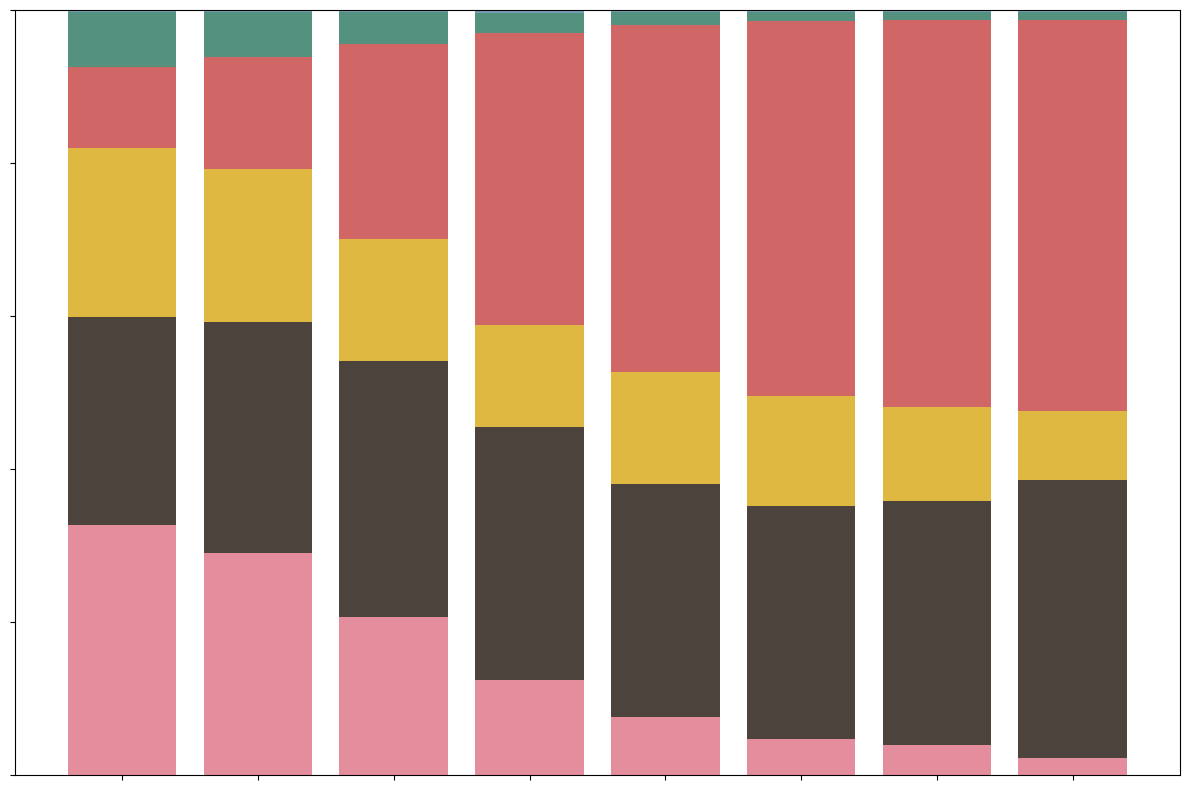

In [36]:
# Paper-ready plot — Zamba2 (no labels, no legend)
fig_zamba2, _ = plot_op_breakdown(zamba2_breakdown, 'Zamba2', color_scheme, annotated=False)
# plt.savefig(f"zamba2_op_breakdown.png", bbox_inches='tight', dpi=300)
plt.show()

## 14. Side-by-Side Comparison: Hymba vs. Zamba2

A two-panel figure showing both models on a common y-axis scale with a shared legend.  
This makes it easy to visually compare how the kernel-time mix differs between the two hybrid architectures across sequence lengths.

Key observations to look for:
- Relative weight of **GEMM** vs **SSM_Scan** as sequence length grows in each model.
- The larger **attention** footprint in Hymba (more interleaved attention heads).
- How Zamba2's shared-transformer design shifts the GEMM fraction at long sequences.

Saved to `profile_data/hymba_vs_zamba2_op_breakdown.png`.

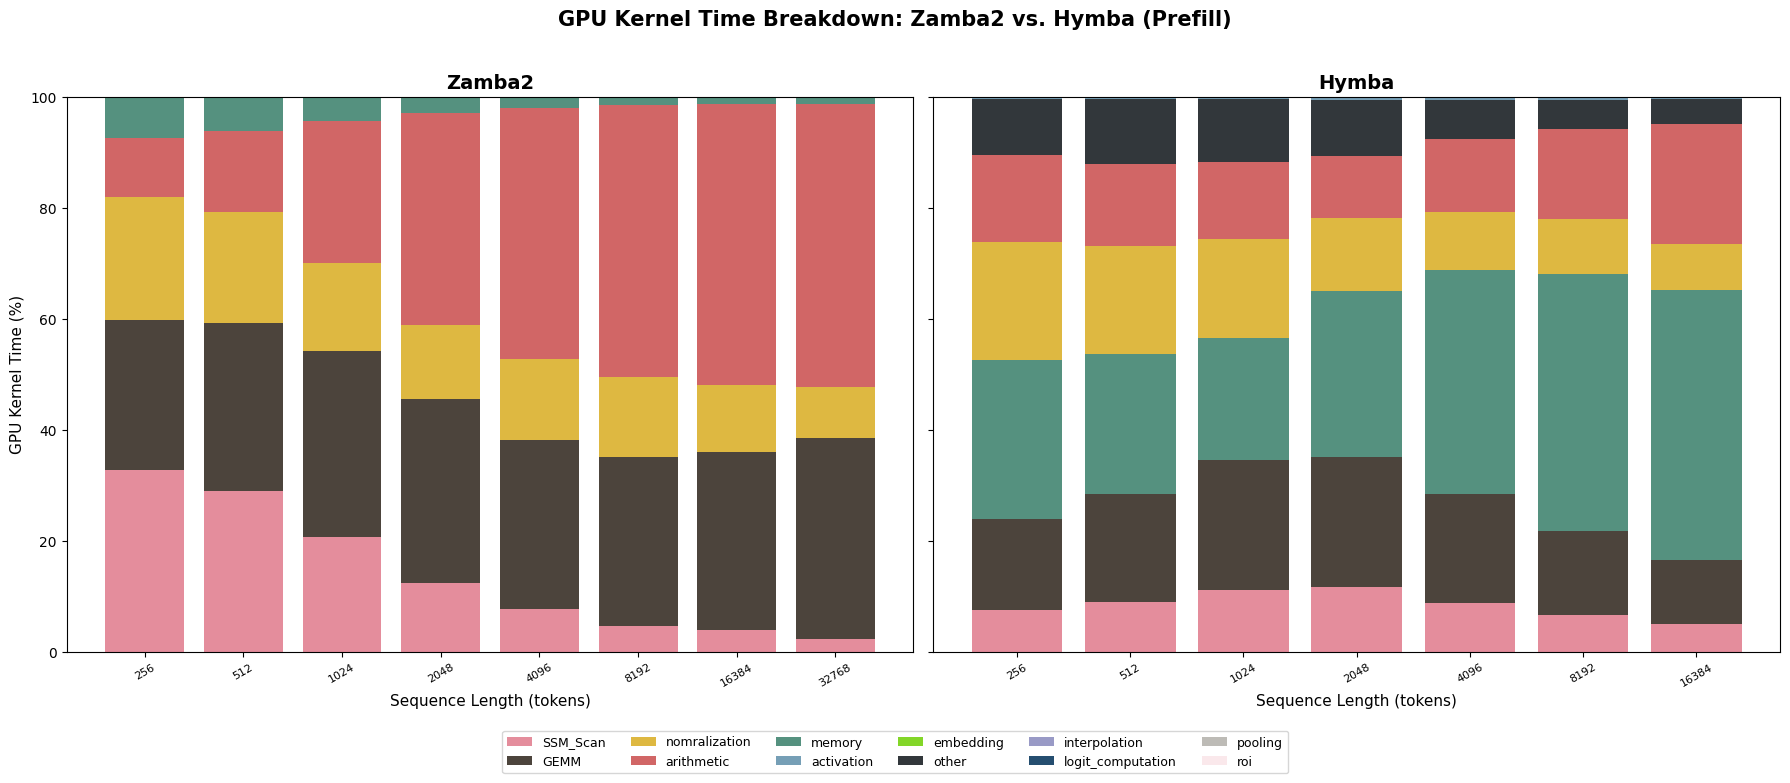

In [37]:
def _bar_stack(ax, breakdown_df, color_scheme):
    """Draw one stacked bar panel (no annotations). Returns the legend handles/labels."""
    seq_lengths = [str(x) for x in breakdown_df.columns]
    other_ops        = [op for op in breakdown_df.index if op not in ('SSM_Scan', 'GEMM')]
    other_ops_sorted = sorted(other_ops,
                              key=lambda x: breakdown_df.loc[x].astype(float).iloc[0], reverse=True)
    op_order = ['SSM_Scan', 'GEMM'] + other_ops_sorted

    bottom  = np.zeros(len(seq_lengths))
    handles, labels = [], []
    for op in op_order:
        if op in breakdown_df.index:
            values = breakdown_df.loc[op].values.astype(float)
            color  = color_scheme.get(op, color_scheme.get('other', '#32373B'))
            bar    = ax.bar(seq_lengths, values, bottom=bottom, label=op, color=color)
            bottom += values
            handles.append(bar[0])
            labels.append(op)
    return handles, labels


fig, (ax_z, ax_h) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

handles_z, labels_z = _bar_stack(ax_z, zamba2_breakdown, color_scheme)
handles_h, labels_h = _bar_stack(ax_h, hymba_breakdown,  color_scheme)

# Titles and axis labels
ax_z.set_title('Zamba2', fontsize=14, fontweight='bold')
ax_h.set_title('Hymba',  fontsize=14, fontweight='bold')
ax_z.set_xlabel('Sequence Length (tokens)', fontsize=11)
ax_h.set_xlabel('Sequence Length (tokens)', fontsize=11)
ax_z.set_ylabel('GPU Kernel Time (%)', fontsize=11)
ax_z.tick_params(axis='x', labelrotation=30, labelsize=8)
ax_h.tick_params(axis='x', labelrotation=30, labelsize=8)

# Merge legend entries from both panels, de-duplicate, preserve order
seen = {}
for h, l in zip(handles_z + handles_h, labels_z + labels_h):
    if l not in seen:
        seen[l] = h
all_handles = list(seen.values())
all_labels  = list(seen.keys())

fig.legend(all_handles, all_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.08),
           ncol=6, fontsize=9, frameon=True)

plt.suptitle('GPU Kernel Time Breakdown: Zamba2 vs. Hymba (Prefill)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"hymba_vs_zamba2_op_breakdown.png",
            bbox_inches='tight', dpi=300)
plt.show()
